In [1]:
import os
import shutil
import pandas as pd
import numpy as np
from tqdm import tqdm

import cv2
from matplotlib import pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
ROOT_FOLDER = '/kaggle/input/datasets/ruii2401/isic-2019'

# Đường dẫn file nhãn (Ground Truth)
TRAIN_CSV = os.path.join(ROOT_FOLDER, 'ISIC_2019_Training_GroundTruth.csv')
TRAIN_META = os.path.join(ROOT_FOLDER, 'ISIC_2019_Training_Metadata.csv')
TEST_CSV = os.path.join(ROOT_FOLDER, 'ISIC_2019_Test_GroundTruth.csv')

train_img_folder = os.path.join(ROOT_FOLDER, 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Input')
test_img_folder = os.path.join(ROOT_FOLDER, 'ISIC_2019_Test_Input', 'ISIC_2019_Test_Input')

WORKING_DIR = ROOT_FOLDER
PROCESSED_DIR = '/kaggle/working/processed_images/'
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Tiền Xử Lý Ảnh

In [3]:
def dull_razor_and_enhance(image_path):
    # Đọc ảnh gốc
    img = cv2.imread(image_path)
    if img is None:
        return None, None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- BƯỚC 1: XÓA LÔNG (Dull Razor - Lec 07: Morphological) ---
    # Chuyển sang ảnh xám để xử lý hình thái học
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Tạo cấu trúc phần tử (Structuring Element) - Lec 07, trang 3
    # Chúng ta dùng kernel 17x17 để quét các sợi lông
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))

    # Phép toán Black-hat: Giúp lấy ra các chi tiết tối (lông) trên nền sáng (da)
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)

    # Tạo Mask (mặt nạ): Chuyển ảnh blackhat về nhị phân
    # Các sợi lông sẽ có màu trắng (255), vùng da có màu đen (0)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)

    # Inpainting: "Vá" ảnh. Thay thế các pixel trắng trong mask bằng
    # các pixel lân cận để xóa sợi lông một cách tự nhiên.
    img_clean = cv2.inpaint(img_rgb, mask, 1, cv2.INPAINT_TELEA)

    # --- BƯỚC 2: KHỬ NHIỄU (Lec 04: Spatial Filtering) ---
    # Dùng Median Filter (Lec 04, trang 35) để khử nhiễu muối tiêu và làm mịn da
    img_smooth = cv2.medianBlur(img_clean, 3)

    # --- BƯỚC 3: TĂNG CƯỜNG TƯƠNG PHẢN (Lec 03: Histogram Transformation) ---
    # Chuyển sang hệ màu LAB để chỉ tác động vào cường độ sáng (L)
    # mà không làm thay đổi màu sắc y tế của bệnh.
    lab = cv2.cvtColor(img_smooth, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    # Áp dụng CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l_enhanced = clahe.apply(l)

    # Gộp lại và chuyển về RGB
    img_final = cv2.merge((l_enhanced, a, b))
    img_final = cv2.cvtColor(img_final, cv2.COLOR_LAB2RGB)

    return img_rgb, img_final

In [4]:
classes = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']

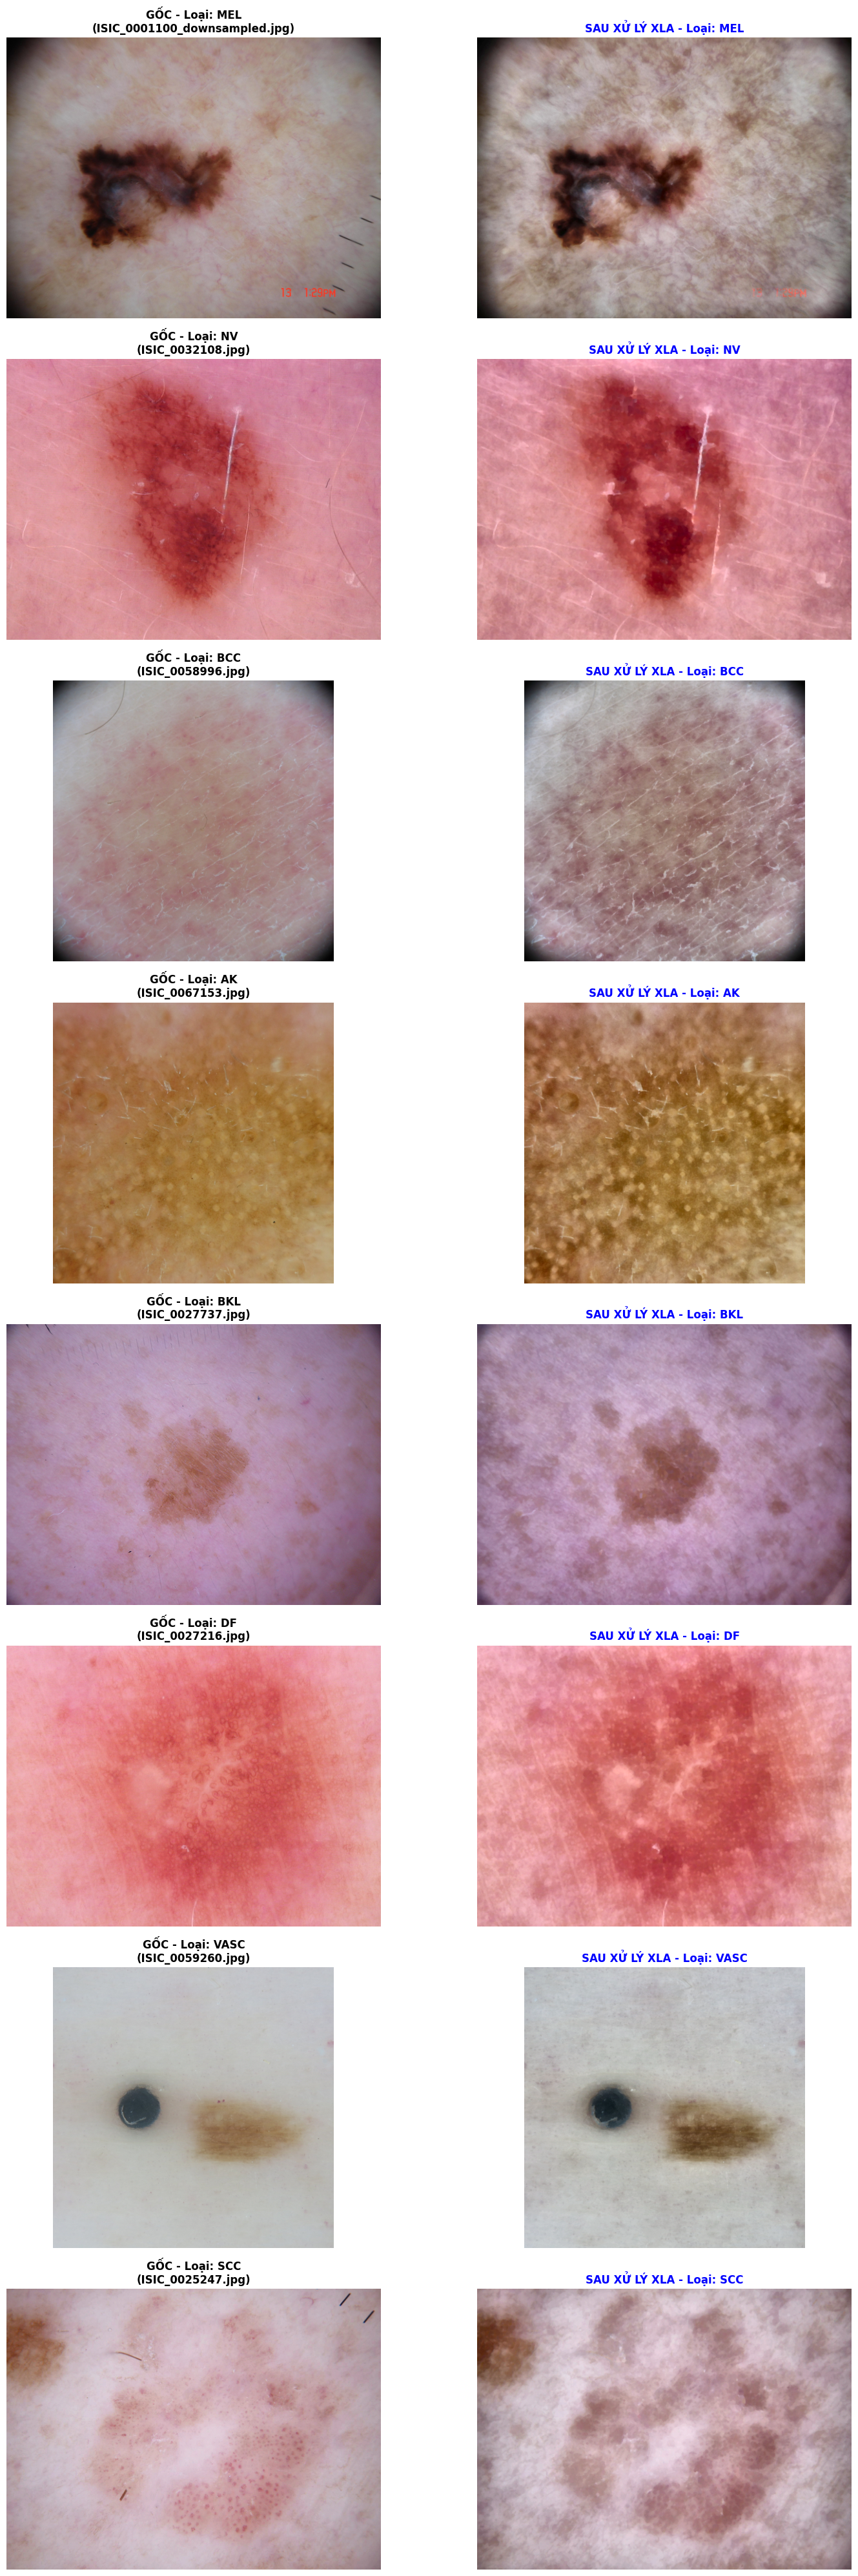

In [5]:
df_train = pd.read_csv(TRAIN_CSV)

def get_8_samples_by_class(df):
    sample_list = []
    for cls in classes:
        # Lọc các ảnh thuộc lớp này
        subset = df[df[cls] == 1.0]
        if not subset.empty:
            # Chọn ngẫu nhiên 1 ảnh
            img_id = subset.sample(1)['image'].values[0]
            # Đảm bảo có đuôi .jpg
            file_name = f"{img_id}.jpg" if not str(img_id).endswith('.jpg') else img_id
            sample_list.append((file_name, cls))
    return sample_list

# 3. THỰC HIỆN LẤY MẪU
samples = get_8_samples_by_class(df_train)

# 4. HIỂN THỊ KẾT QUẢ SO SÁNH (8 hàng x 2 cột)
plt.figure(figsize=(16, 40))

for i, (file_name, cls_name) in enumerate(samples):
    # Đường dẫn ảnh gốc trong folder đã giải nén
    path = os.path.join(train_img_folder, file_name)

    # Thực hiện tiền xử lý XLA
    orig, proc = dull_razor_and_enhance(path)

    if orig is not None:
        # Cột bên trái: Ảnh gốc
        plt.subplot(8, 2, 2*i + 1)
        plt.imshow(orig)
        plt.title(f"GỐC - Loại: {cls_name}\n({file_name})", fontsize=12, fontweight='bold')
        plt.axis('off')

        # Cột bên phải: Ảnh sau xử lý
        plt.subplot(8, 2, 2*i + 2)
        plt.imshow(proc)
        plt.title(f"SAU XỬ LÝ XLA - Loại: {cls_name}", fontsize=12, color='blue', fontweight='bold')
        plt.axis('off')
    else:
        print(f"⚠️ Không tìm thấy file: {path}")

plt.tight_layout()
plt.show()

In [6]:
df_full = pd.read_csv(TRAIN_CSV)
df_full = df_full[df_full['UNK'] != 1.0]
df_sample = df_full.copy()   # dùng toàn bộ, không sample nữa
df_sample['image_file'] = df_sample['image'].apply(lambda x: f"{x}.jpg")

TOTAL_COUNT = len(df_sample)
print(f"📊 Tổng số ảnh sẽ xử lý: {TOTAL_COUNT}")

# 3. LÀM SẠCH THƯ MỤC ĐẦU RA (Xóa cũ tạo mới)
if os.path.exists(PROCESSED_DIR):
    shutil.rmtree(PROCESSED_DIR)
os.makedirs(PROCESSED_DIR, exist_ok=True)

# 4. VÒNG LẶP XỬ LÝ XLA (DIP)
print(f"🚀 Bắt đầu xử lý XLA cho {TOTAL_COUNT} ảnh...")

for _, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    img_name = row['image_file']
    input_path = os.path.join(train_img_folder, img_name)
    output_path = os.path.join(PROCESSED_DIR, img_name)

    if os.path.exists(input_path):
        _, processed_img = dull_razor_and_enhance(input_path)
        if processed_img is not None:
            processed_img_resized = cv2.resize(processed_img, (224, 224))
            cv2.imwrite(output_path, cv2.cvtColor(processed_img_resized, cv2.COLOR_RGB2BGR))

print(f"\n✅ Xử lý xong! {len(os.listdir(PROCESSED_DIR))} ảnh sạch đã sẵn sàng tại: {PROCESSED_DIR}")

📊 Tổng số ảnh sẽ xử lý: 25331
🚀 Bắt đầu xử lý XLA cho 25331 ảnh...


100%|██████████| 25331/25331 [34:14<00:00, 12.33it/s]


✅ Xử lý xong! 25331 ảnh sạch đã sẵn sàng tại: /kaggle/working/processed_images/


In [7]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Conv2D, Dense, Dropout

# 1. ĐỊNH NGHĨA LỚP SOFT ATTENTION (Đã tích hợp Global Sum Pooling)
class SoftAttention(Layer):
    def __init__(self, **kwargs):
        super(SoftAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        # input_shape: (batch, h, w, ch)
        # Conv 1x1 để tính điểm năng lượng e_ij
        self.energy_conv = Conv2D(
            filters=1,
            kernel_size=(1, 1),
            padding='same',
            activation='linear',
            name='energy_score'
        )
        super(SoftAttention, self).build(input_shape)

    def call(self, x):
        # Bước 1: Tính năng lượng e_ij
        e = self.energy_conv(x)  # (batch, h, w, 1)

        # Bước 2: Chuẩn hóa Softmax trên toàn bộ không gian (H*W)
        orig_shape = tf.shape(e)
        b, h, w, c = orig_shape[0], orig_shape[1], orig_shape[2], orig_shape[3]

        flat = tf.reshape(e, (b, h * w, c))
        softmax_flat = tf.nn.softmax(flat, axis=1)
        alpha = tf.reshape(softmax_flat, (b, h, w, c))  # (batch, h, w, 1)

        # Bước 3: Nhân trọng số attention vào feature map gốc
        F_att = x * alpha  # (batch, h, w, ch)

        # Bước 4: Tích hợp Global Sum Pooling tạo ra Vector ngữ cảnh
        # Tính tổng theo chiều không gian (axis 1 và 2 tương ứng với h và w)
        context_vector = tf.reduce_sum(F_att, axis=[1, 2])
        
        return context_vector # Kết quả là vector 1D (batch, ch)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

    def get_config(self):
        return super(SoftAttention, self).get_config()

In [8]:
def build_hybrid_model(num_classes=8):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    
    # Giai đoạn 1: đóng băng toàn bộ mạng nền
    base_model.trainable = False

    inputs = base_model.input
    f = base_model.output

    # Đi qua lớp Attention (Lớp này đã tự động giảm chiều dữ liệu bằng Sum Pooling)
    F_att = SoftAttention(name='soft_attention')(f)
    
    # BỎ DÒNG NÀY: x = GlobalAveragePooling2D()(F_att)
    
    # Đưa thẳng F_att vào Dropout và Dense
    x = Dropout(0.3)(F_att)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=predictions)
    
    # trả về cả base_model để rã đông ở Giai đoạn 2
    return base_model, model

print("🚀 Bắt đầu Giai đoạn 1: Khởi động lớp Attention...")
base_model, model = build_hybrid_model(num_classes=8)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

🚀 Bắt đầu Giai đoạn 1: Khởi động lớp Attention...


I0000 00:00:1785588210.576130      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785588210.579173      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,268,232 (8.65 MB)

 Trainable params: 10,248 (40.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

label_columns = classes

# 1. BỔ SUNG DATA AUGMENTATION CHO TẬP TRAIN (Chống Học vẹt)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,        # Xoay ảnh ngẫu nhiên tối đa 20 độ
    width_shift_range=0.1,    # Dịch chuyển ảnh theo chiều ngang 10%
    height_shift_range=0.1,   # Dịch chuyển ảnh theo chiều dọc 10%
    horizontal_flip=True,     # Tự động lật ngang ảnh
    zoom_range=0.1            # Phóng to/thu nhỏ ngẫu nhiên 10%
)

# 2. TẬP VALIDATION (Chỉ áp dụng tiền xử lý chuẩn, KHÔNG biến đổi ảnh)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# 3. CHIA DỮ LIỆU
train_df, val_df = train_test_split(df_sample, test_size=0.2, random_state=42)

print(f"📊 Kiểm tra số lượng dòng trong Dataframe:")
print(f"- Tập Train: {len(train_df)} dòng")
print(f"- Tập Val: {len(val_df)} dòng")

# 4. KHỞI TẠO LUỒNG DỮ LIỆU ĐỂ HUẤN LUYỆN
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=PROCESSED_DIR,
    x_col="image_file",
    y_col=label_columns,
    target_size=(224, 224),
    batch_size=32,
    class_mode="raw"
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=PROCESSED_DIR,
    x_col="image_file",
    y_col=label_columns,
    target_size=(224, 224),
    batch_size=32,
    class_mode="raw"
)

📊 Kiểm tra số lượng dòng trong Dataframe:
- Tập Train: 20264 dòng
- Tập Val: 5067 dòng
Found 20264 validated image filenames.
Found 5067 validated image filenames.


In [10]:
from sklearn.utils.class_weight import compute_class_weight

# Lấy class index (0-7) cho từng ảnh trong tập train, dựa trên cột one-hot
y_train_integers = train_df[classes].values.argmax(axis=1)

# Tính trọng số nghịch đảo theo tần suất xuất hiện của từng lớp
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_integers),
    y=y_train_integers
)

# Chuyển thành dict {index_lớp: trọng_số} — đúng định dạng model.fit() cần
class_weight_dict = dict(enumerate(class_weights_array))

print("📊 Trọng số từng lớp (class_weight):")
for i, cls_name in enumerate(classes):
    print(f"  {cls_name}: {class_weight_dict[i]:.3f}")

📊 Trọng số từng lớp (class_weight):
  MEL: 0.702
  NV: 0.246
  BCC: 0.950
  AK: 3.671
  BKL: 1.213
  DF: 13.262
  VASC: 13.262
  SCC: 4.834


In [11]:
# Tính toán chính xác số bước cho mỗi epoch
train_steps = len(train_df) // 32
val_steps = len(val_df) // 32

print("\n🚀 BẮT ĐẦU GIAI ĐOẠN 1: Khởi động lớp Attention và Classifier...")
base_model, model = build_hybrid_model(num_classes=8)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 1. Bổ sung cơ chế lưu mô hình tốt nhất cho Giai đoạn 1
callbacks_phase1 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='/kaggle/working/best_phase1_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

train_generator.reset()
val_generator.reset()

history_phase1 = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    epochs=15, # Cho phép học tối đa 15 epoch, EarlyStopping sẽ tự động ngắt nếu đủ tốt
    validation_data=val_generator,
    validation_steps=val_steps,
    callbacks=callbacks_phase1,
    class_weight=class_weight_dict
)

print("\n🚀 BẮT ĐẦU GIAI ĐOẠN 2: Tinh chỉnh vi chỉnh (Fine-Tuning) các lớp sâu...")

# 2. RÃ ĐÔNG TĂNG DẦN: Chỉ mở khóa 55 lớp cuối của MobileNetV2 (từ lớp 100 trở đi)
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

# Compile lại mô hình với tốc độ học (learning rate) cực nhỏ
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='/kaggle/working/best_hybrid_model_finetuned.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

train_generator.reset()
val_generator.reset()

history_phase2 = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    epochs=50, 
    validation_data=val_generator,
    validation_steps=val_steps,
    callbacks=callbacks_phase2,
    class_weight=class_weight_dict
)



🚀 BẮT ĐẦU GIAI ĐOẠN 1: Khởi động lớp Attention và Classifier...
Epoch 1/15


2026-08-01 12:43:54.459051: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-01 12:43:54.596420: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1785588237.183573      78 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 94/633 ━━━━━━━━━━━━━━━━━━━━ 2:57 329ms/step - accuracy: 0.1876 - loss: 2.3387

2026-08-01 12:44:36.928724: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-01 12:44:37.064149: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.2765 - loss: 2.0474
Epoch 1: val_accuracy improved from None to 0.41001, saving model to /kaggle/working/best_phase1_model.h5


...


Epoch 2: finished saving model to /kaggle/working/best_phase1_model.h5
633/633 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4375 - loss: 0.9166 - val_accuracy: 0.4163 - val_loss: 1.6572
Epoch 3/15
633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.4226 - loss: 1.6052
Epoch 3: val_accuracy improved from 0.41634 to 0.50732, saving model to /kaggle/working/best_phase1_model.h5



Epoch 3: finished saving model to /kaggle/working/best_phase1_model.h5
633/633 ━━━━━━━━━━━━━━━━━━━━ 214s 339ms/step - accuracy: 0.4209 - loss: 1.6013 - val_accuracy: 0.5073 - val_loss: 1.3720
Epoch 4/15
  1/633 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.4375 - loss: 1.2237
Epoch 4: val_accuracy improved from 0.50732 to 0.50752, saving model to /kaggle/working/best_phase1_model.h5



Epoch 4: finished saving model to /kaggle/working/best_phase1_model.h5
633/633 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4375 - loss: 1.2237 - val_accuracy: 0.5075 - val_loss: 1.3613
Epoch 5/15
633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.4377 - loss: 1.4701
Epoch 5: val_accuracy did not improve from 0.50752
633/633 ━━━━━━━━━━━━━━━━━━━━ 215s 340ms/step - accuracy: 0.4277 - loss: 1.5255 - val_accuracy: 0.4335 - val_loss: 1.5223
Epoch 6/15
  1/633 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.5938 - loss: 0.8990
Epoch 6: val_accuracy did not improve from 0.50752
633/633 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5938 - loss: 0.8990 - val_accuracy: 0.4241 - val_loss: 1.5383
Epoch 7/15
633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.4360 - loss: 1.4914
Epoch 7: val_accuracy did not improve from 0.50752
633/633 ━━━━━━━━━━━━━━━━━━━━ 216s 342ms/step - accuracy: 0.4426 - loss: 1.4980 - val_accuracy: 0.4927 - val_loss: 1.4131
Epoch 8/15
  1/633 ━━━━━━━━━━━━━━


Epoch 1: finished saving model to /kaggle/working/best_hybrid_model_finetuned.h5
633/633 ━━━━━━━━━━━━━━━━━━━━ 263s 377ms/step - accuracy: 0.4456 - loss: 2.2730 - val_accuracy: 0.4419 - val_loss: 1.5219 - learning_rate: 1.0000e-05
Epoch 2/50
  1/633 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.5000 - loss: 1.3681
Epoch 2: val_accuracy improved from 0.44185 to 0.44343, saving model to /kaggle/working/best_hybrid_model_finetuned.h5



Epoch 2: finished saving model to /kaggle/working/best_hybrid_model_finetuned.h5
633/633 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5000 - loss: 1.3681 - val_accuracy: 0.4434 - val_loss: 1.5197 - learning_rate: 1.0000e-05
Epoch 3/50
633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.4101 - loss: 1.7923
Epoch 3: val_accuracy did not improve from 0.44343
633/633 ━━━━━━━━━━━━━━━━━━━━ 222s 350ms/step - accuracy: 0.3970 - loss: 1.7894 - val_accuracy: 0.3801 - val_loss: 1.6455 - learning_rate: 1.0000e-05
Epoch 4/50
  1/633 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.4688 - loss: 1.1040
Epoch 4: val_accuracy did not improve from 0.44343
633/633 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4688 - loss: 1.1040 - val_accuracy: 0.3811 - val_loss: 1.6429 - learning_rate: 1.0000e-05
Epoch 5/50
633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.3930 - loss: 1.7439
Epoch 5: val_accuracy did not improve from 0.44343
633/633 ━━━━━━━━━━━━━━━━━━━━ 214s 338ms/step - accuracy: 0.3

#Test

🔄 Đang nạp file Ground Truth của tập Test...
Tổng mẫu test gốc: 8238 | Dùng để đánh giá: 6191 ảnh (100% thuộc 8 lớp đã biết)
🛠️ Đang xử lý DIP (Dull Razor + CLAHE) cho 6191 mẫu test...


100%|██████████| 6191/6191 [09:05<00:00, 11.35it/s]



🧠 AI đang dự đoán...


  0%|          | 0/6191 [00:00<?, ?it/s]2026-08-01 13:24:08.040825: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-01 13:24:08.174681: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
100%|██████████| 6191/6191 [09:21<00:00, 11.03it/s]



📊 CLOSED-SET: 6191 mẫu (100% thuộc 8 lớp đã biết, không lẫn UNK)


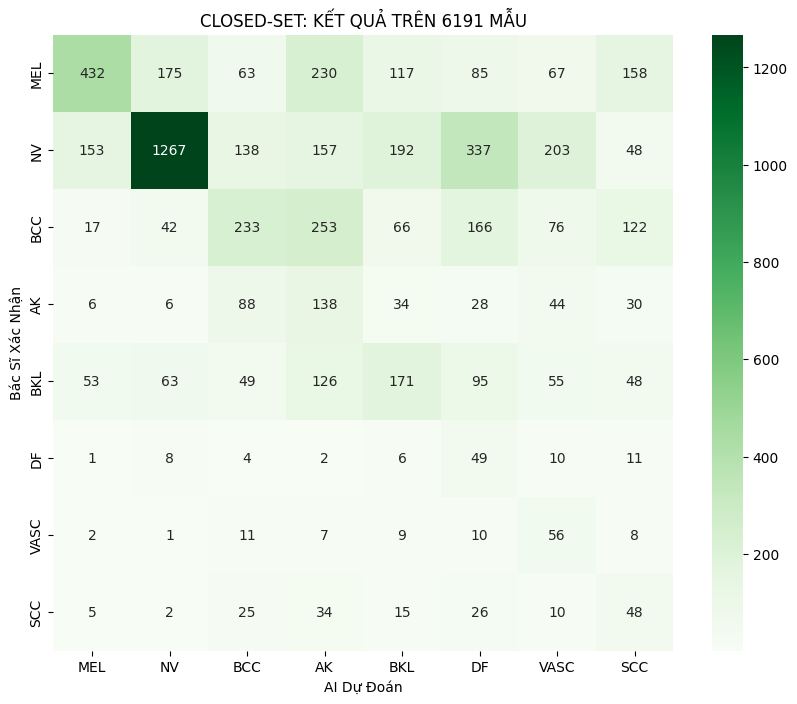


📊 BÁO CÁO CHI TIẾT:
              precision    recall  f1-score   support

         MEL       0.65      0.33      0.43      1327
          NV       0.81      0.51      0.62      2495
         BCC       0.38      0.24      0.29       975
          AK       0.15      0.37      0.21       374
         BKL       0.28      0.26      0.27       660
          DF       0.06      0.54      0.11        91
        VASC       0.11      0.54      0.18       104
         SCC       0.10      0.29      0.15       165

    accuracy                           0.39      6191
   macro avg       0.32      0.38      0.28      6191
weighted avg       0.57      0.39      0.44      6191



In [12]:
# --- 0. LOAD LẠI ĐÚNG BẢN TỐT NHẤT ĐÃ LƯU ---
model.load_weights('/kaggle/working/best_hybrid_model_finetuned.h5')

# --- 1. CẤU HÌNH ---
CLASSES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']   # 8 lớp, không có UNK
PROCESSED_FINAL_TEST_DIR = '/kaggle/working/final_test_images_real/'
ROOT_FOLDER = '/kaggle/input/datasets/ruii2401/isic-2019'
test_img_folder = os.path.join(ROOT_FOLDER, 'ISIC_2019_Test_Input', 'ISIC_2019_Test_Input')

print("🔄 Đang nạp file Ground Truth của tập Test...")
df_test_full = pd.read_csv(TEST_CSV)

# --- 2. LOẠI UNK, DÙNG TOÀN BỘ PHẦN CÒN LẠI (không sample nữa) ---
df_test_sample = df_test_full[df_test_full['UNK'] != 1.0].copy()
print(f"Tổng mẫu test gốc: {len(df_test_full)} | Dùng để đánh giá: {len(df_test_sample)} ảnh (100% thuộc 8 lớp đã biết)")

# --- 3. XỬ LÝ DIP ---
if os.path.exists(PROCESSED_FINAL_TEST_DIR):
    shutil.rmtree(PROCESSED_FINAL_TEST_DIR)
os.makedirs(PROCESSED_FINAL_TEST_DIR, exist_ok=True)

print(f"🛠️ Đang xử lý DIP (Dull Razor + CLAHE) cho {len(df_test_sample)} mẫu test...")
for _, row in tqdm(df_test_sample.iterrows(), total=len(df_test_sample)):
    img_id = row['image']
    input_path = os.path.join(test_img_folder, f"{img_id}.jpg")
    output_path = os.path.join(PROCESSED_FINAL_TEST_DIR, f"{img_id}.jpg")
    if os.path.exists(input_path):
        _, proc = dull_razor_and_enhance(input_path)
        if proc is not None:
            proc = cv2.resize(proc, (224, 224))
            cv2.imwrite(output_path, cv2.cvtColor(proc, cv2.COLOR_RGB2BGR))

# --- 4. DỰ ĐOÁN ---
y_true_closed, y_pred_closed = [], []
sample_confidences = []
sample_top_idx = []

print("\n🧠 AI đang dự đoán...")
for _, row in tqdm(df_test_sample.iterrows(), total=len(df_test_sample)):
    img_id = row['image']
    img_path = os.path.join(PROCESSED_FINAL_TEST_DIR, f"{img_id}.jpg")
    if not os.path.exists(img_path):
        continue

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = preprocess_input(img.astype(np.float32))
    img = np.expand_dims(img, axis=0)

    preds = model.predict(img, verbose=0)[0]
    top_idx = np.argmax(preds)
    confidence = preds[top_idx]

    true_idx = np.argmax(row[CLASSES].values)

    y_true_closed.append(true_idx)
    y_pred_closed.append(top_idx)
    sample_confidences.append(confidence)
    sample_top_idx.append(top_idx)

sample_confidences = np.array(sample_confidences)
sample_top_idx = np.array(sample_top_idx)

# --- 5. VẼ MA TRẬN NHẦM LẪN ---
print(f"\n📊 CLOSED-SET: {len(y_true_closed)} mẫu (100% thuộc 8 lớp đã biết, không lẫn UNK)")
plt.figure(figsize=(10, 8))
cm_closed = confusion_matrix(y_true_closed, y_pred_closed)
sns.heatmap(cm_closed, annot=True, fmt='d', cmap='Greens', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f'CLOSED-SET: KẾT QUẢ TRÊN {len(y_true_closed)} MẪU')
plt.xlabel('AI Dự Đoán')
plt.ylabel('Bác Sĩ Xác Nhận')
plt.show()

# --- 6. BÁO CÁO CHI TIẾT ---
print("\n📊 BÁO CÁO CHI TIẾT:")
present_labels = np.unique(np.concatenate((y_true_closed, y_pred_closed)))
present_names = [CLASSES[i] for i in present_labels]
print(classification_report(y_true_closed, y_pred_closed, labels=present_labels, target_names=present_names))